### NAME: Se Rang Seo
### Title: Assignment 9 Linear Regression
### Course: Phys255 Machine Learning
### Instructor: Professor Romanowsky

### Instructions
Find a scientific data-set suitable for regression analysis.  For example, you could include "regression" in a keyword search in <a href="https://www.kaggle.com/datasets/ignaciovinuales/battery-remaining-useful-life-rul" target="_blank">Kaggle</a> to an external site..  Try to have more than one predictor X.
Examine your data, discussing the statistics of the predictors.  Visualize with relevant plots. 
Select and apply a regression method, and visualize your fit.  
Use cross-validation and hyperparameter grid search to optimize bias and variance.  Also employ a learning curve.
Repeat with as many varieties of regression as are relevant, including regularization.
Discuss the relative performance, strengths, and weaknesses of the different methods, in the context of the scientific goals.
Upload your data-file, Jupyter Notebook, and answers to these questions (which can be in either the Notebook or a separate document).

### Battery Remaining Useful Life (RUL)
The Hawaii Natural Energy Institute examined 14 NMC-LCO 18650 batteries with a nominal capacity of 2.8 Ah, which were cycled over 1000 times at 25°C with a CC-CV charge rate of C/2 rate and discharge rate of 1.5C.

From that source dataset, I created features that showcase the voltage and current behaviour over each cycle. Those features can be used to predict the remaining useful life (RUL) of the batteries. The dataset contains the summary of the 14 batteries.

### Imports

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [71]:
data = pd.read_csv("Battery_RUL.csv")

data

,Cycle_Index,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,1.0,2595.30,1151.488500,3.670,3.211,5460.001,6755.01,10777.82,1112
1,2.0,7408.64,1172.512500,4.246,3.220,5508.992,6762.02,10500.35,1111
2,3.0,7393.76,1112.992000,4.249,3.224,5508.993,6762.02,10420.38,1110
3,4.0,7385.50,1080.320667,4.250,3.225,5502.016,6762.02,10322.81,1109
4,6.0,65022.75,29813.487000,4.290,3.398,5480.992,53213.54,56699.65,1107
...,...,...,...,...,...,...,...,...,...
15059,1108.0,770.44,179.523810,3.773,3.742,922.775,1412.38,6678.88,4
15060,1109.0,771.12,179.523810,3.773,3.744,915.512,1412.31,6670.38,3
15061,1110.0,769.12,179.357143,3.773,3.742,915.513,1412.31,6637.12,2
15062,1111.0,773.88,162.374667,3.763,3.839,539.375,1148.00,7660.62,1


<Figure size 640x480 with 0 Axes>

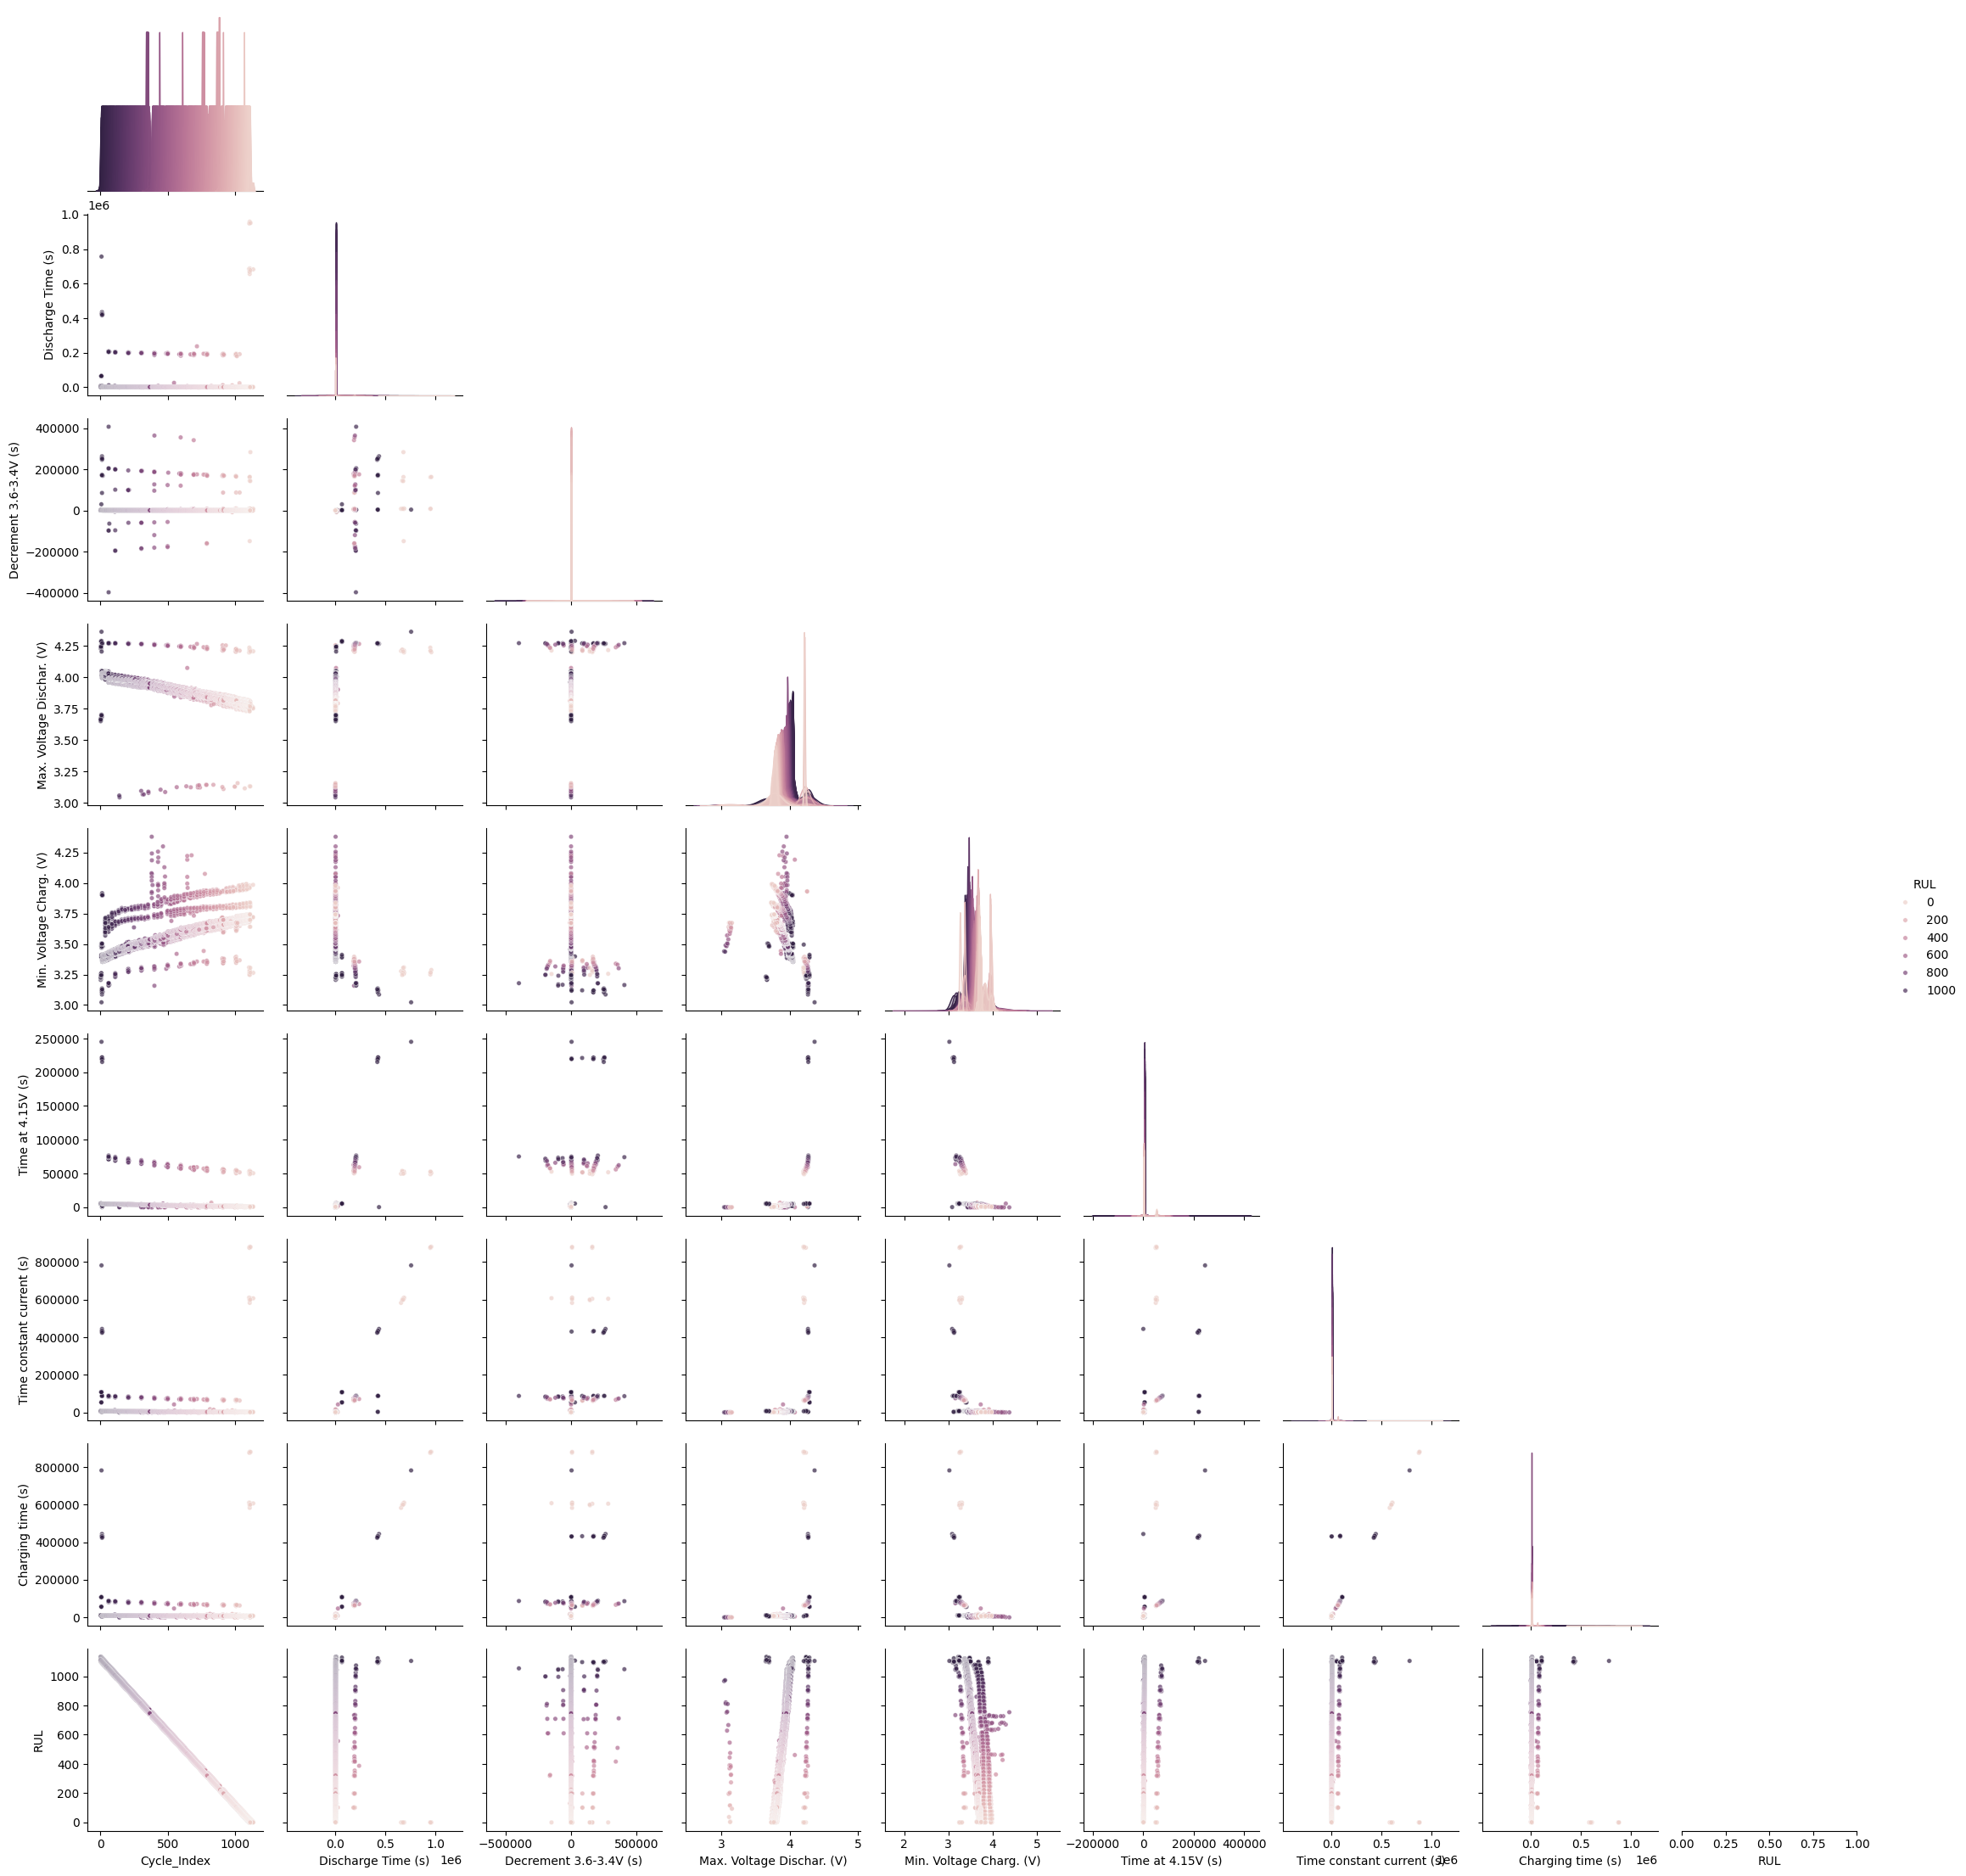

In [72]:
# Assuming 'targets' is your target column name, it should be a string

target_column = 'RUL'  # Replace with your actual target column name
cols = []

for i in range(0,len(data.columns)):
      cols.append(data.columns[i])

fig3 = plt.figure()
p = sns.pairplot(data, 
                 vars=cols,
                 corner=True, 
                 hue=target_column,  # This should be a string, not a Series
                 plot_kws={"s": 15, "alpha": 0.7})

In [75]:
X = data.drop('RUL', axis=1)  # All columns except target

y = data['RUL']  # Target variable

In [77]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

Text(0.5, 1.0, 'Actual vs Predicted RUL')

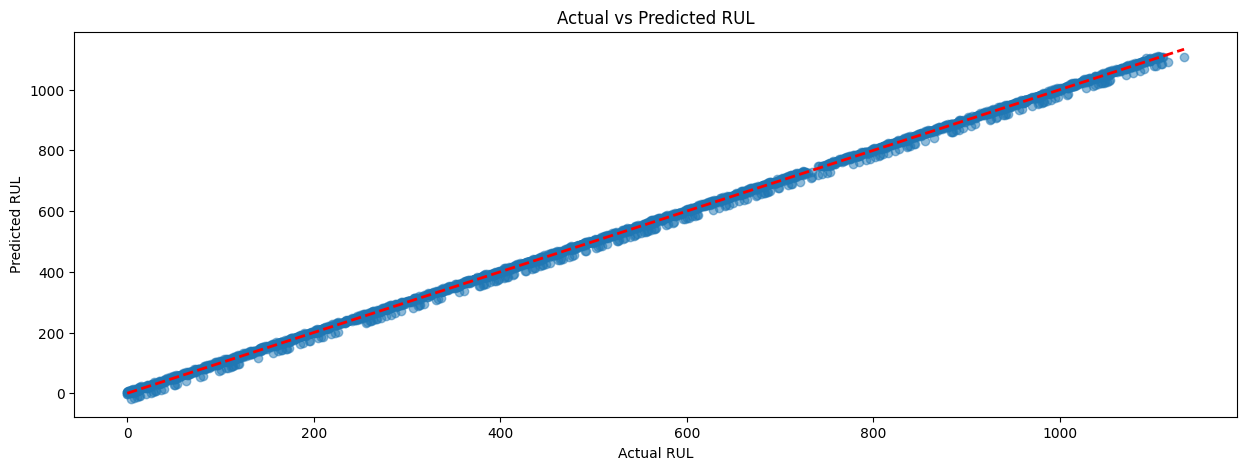

In [78]:
# Plot Actual vs Predicted
plt.figure(figsize=(15, 5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.title('Actual vs Predicted RUL')

In [79]:
# Show first few predictions vs actual
results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10],
    'Difference': y_test.values[:10] - y_pred[:10]
})
print("\nFirst 10 predictions:")
print(results)


First 10 predictions:
   Actual    Predicted  Difference
0    1043  1045.313190   -2.313190
1     956   932.319605   23.680395
2     469   474.379608   -5.379608
3     176   172.365483    3.634517
4     943   948.330871   -5.330871
5     617   622.367789   -5.367789
6     207   209.356679   -2.356679
7      32    34.253597   -2.253597
8      23    25.374695   -2.374695
9      22    27.417389   -5.417389
